# ![Machine Learning Lab](banner.jpg)

# Laboratorio 7 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab7.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar un Perceptrón Multicapa (MLP) para clasificación multiclase.
2. Implementar el mismo modelo en dos frameworks: **PyTorch** y **TensorFlow/Keras**.
3. Evaluar y comparar el desempeño de ambos modelos.

---

En esta ocasión trabajaremos con el dataset **Blood Cell Anomaly Detection 2025**, que contiene 5,880 registros de células sanguíneas con 36 características morfológicas, clínicas y de adquisición. El objetivo es clasificar cada registro en uno de los **19 tipos de célula** disponibles.

Dataset: [Blood Cell Anomaly Detection 2025](https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el archivo `blood_cell_anomaly_detection.csv` desde Kaggle.
2. Carga el CSV en un DataFrame y muestra las primeras filas.
3. Identifica la columna objetivo (`cell_type`) y muestra la distribución de las 19 clases.
4. ¿Cuántas características numéricas y categóricas tiene el dataset? ¿Hay valores faltantes?

---

### 2. Preprocesamiento de datos (20%)

Las siguientes columnas **no deben usarse** como features: `anomaly_label`, `disease_category`, `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score`.

1. Elimina las columnas mencionadas y el identificador (`cell_id`).
2. Normaliza las features numéricas (escalar al rango [0,1] o estandarizar).
3. Aplica **one-hot encoding** a las features categóricas y combínalas con las numéricas.
4. Codifica la columna objetivo (`cell_type`) como valores numéricos.
5. Divide los datos en conjunto de entrenamiento (80%) y prueba (20%). Utiliza `random_state = 42`

---

### 3. MLP con PyTorch (30%)

1. Convierte los datos de entrenamiento y prueba a tensores de PyTorch y crea DataLoaders.
2. Construye un MLP usando `nn.Module` con al menos 2 capas ocultas y activación ReLU.
3. ¿Cuántos parámetros tiene la red? Muestra la cantidad de parametros por cada capa.
4. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
5. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 4. MLP con TensorFlow/Keras (30%)

1. Construye un MLP equivalente al anterior usando la API Sequential de Keras.
2. Compila el modelo con el optimizador y función de pérdida adecuados.
3. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
4. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 5. Comparación de resultados (10%)

1. Genera la matriz de confusión para los modelos MLP.
2. ¿Cuáles tipos de célula son más difíciles de clasificar? ¿Son los mismos en ambos modelos?
3. Compara la precisión obtenida con PyTorch vs TensorFlow.

---


# **1. Carga y exploración de datos**

Carga del conjunto de datos **Blood Cell Anomaly Detection** haciendo uso del archivo **csv** disponible

In [119]:
%matplotlib inline

In [120]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [121]:
blood_data = pd.read_csv("../datasets/blood_cell_anomaly_detection.csv")

Visualización de las primeras **5 filas** del conjunto de datos

In [122]:
blood_data.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


Identificación de la variable objetivo **Cell Type**

In [123]:
blood_data["cell_type"].value_counts(normalize = True)

cell_type
Neutrophil                   0.187075
Normal_RBC                   0.153061
Lymphocyte                   0.144558
Monocyte                     0.068027
Platelet                     0.051020
Eosinophil                   0.051020
Blast_Cell                   0.047619
Elliptocyte                  0.034014
Prolymphocyte                0.030612
Schistocyte                  0.028912
Hypersegmented_Neutrophil    0.027211
Reactive_Lymphocyte          0.025510
Basophil                     0.025510
Spherocyte                   0.025510
Toxic_Granulation            0.023810
Sickle_Cell                  0.023810
Target_Cell                  0.022109
Smudge_Cell                  0.017007
Artefact                     0.013605
Name: proportion, dtype: float64

Visualización de la distribución de clases de la variable objetivo

In [124]:
labels = blood_data["cell_type"].values

unique, counts = np.unique(labels, return_counts = True)

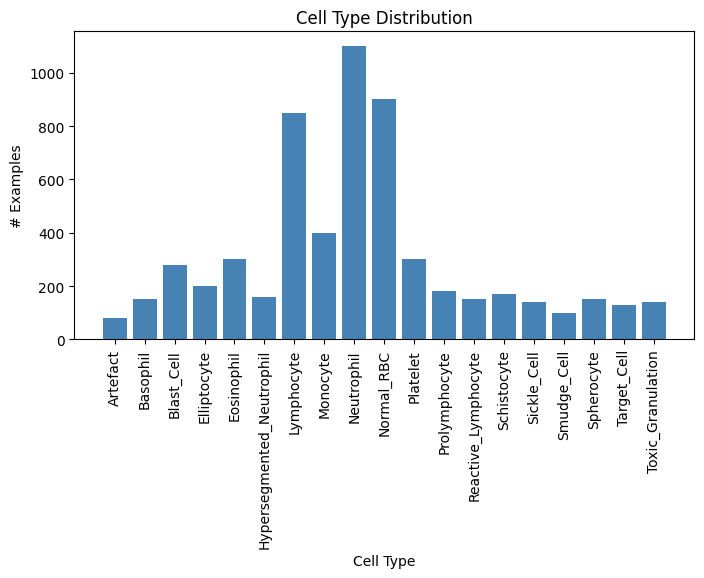

In [125]:
plt.figure(figsize = (8, 4))
plt.bar(unique, counts, color = "steelblue")

plt.xlabel("Cell Type")
plt.ylabel("# Examples")

plt.title("Cell Type Distribution")

plt.xticks(rotation = 90)

plt.show()

In [126]:
for cell_type, count in zip(unique, counts):
    print(f'Type --{cell_type}-- : {count} examples')

Type --Artefact-- : 80 examples
Type --Basophil-- : 150 examples
Type --Blast_Cell-- : 280 examples
Type --Elliptocyte-- : 200 examples
Type --Eosinophil-- : 300 examples
Type --Hypersegmented_Neutrophil-- : 160 examples
Type --Lymphocyte-- : 850 examples
Type --Monocyte-- : 400 examples
Type --Neutrophil-- : 1100 examples
Type --Normal_RBC-- : 900 examples
Type --Platelet-- : 300 examples
Type --Prolymphocyte-- : 180 examples
Type --Reactive_Lymphocyte-- : 150 examples
Type --Schistocyte-- : 170 examples
Type --Sickle_Cell-- : 140 examples
Type --Smudge_Cell-- : 100 examples
Type --Spherocyte-- : 150 examples
Type --Target_Cell-- : 130 examples
Type --Toxic_Granulation-- : 140 examples


Evaluación de la calidad del conjunto de datos

In [127]:
print("ROWS: ", blood_data.shape[0])
print("COLUMNS: ", blood_data.shape[1])

ROWS:  5880
COLUMNS:  36


Revisión de los tipos de datos de las variables que conforman el conjunto de datos

In [128]:
blood_data.dtypes

cell_id                                        str
cell_type                                      str
anomaly_label                                int64
disease_category                               str
cell_diameter_um                           float64
nucleus_area_pct                           float64
chromatin_density                          float64
cytoplasm_ratio                            float64
circularity                                float64
eccentricity                               float64
granularity_score                          float64
lobularity_score                           float64
membrane_smoothness                        float64
cell_area_px                                 int64
perimeter_px                                 int64
mean_r                                       int64
mean_g                                       int64
mean_b                                       int64
stain_intensity                            float64
patient_age_group              

In [129]:
num_cols = blood_data.select_dtypes(include = ["int64", "float64"]).columns
cat_cols = blood_data.select_dtypes(include = ["str", "object"]).columns

In [130]:
print("NUMERICAL:", len(num_cols))
print("CATEGORICAL:", len(cat_cols))

NUMERICAL: 28
CATEGORICAL: 8


Revisión de los porcentajes de valores faltantes asociados a las variables presentes en el conjunto de datos

In [131]:
missing_pct = (blood_data.isnull().sum() / len(blood_data)) * 100
print(missing_pct)

cell_id                                    0.0
cell_type                                  0.0
anomaly_label                              0.0
disease_category                           0.0
cell_diameter_um                           0.0
nucleus_area_pct                           0.0
chromatin_density                          0.0
cytoplasm_ratio                            0.0
circularity                                0.0
eccentricity                               0.0
granularity_score                          0.0
lobularity_score                           0.0
membrane_smoothness                        0.0
cell_area_px                               0.0
perimeter_px                               0.0
mean_r                                     0.0
mean_g                                     0.0
mean_b                                     0.0
stain_intensity                            0.0
patient_age_group                          0.0
patient_sex                                0.0
wbc_count_per

| Pregunta | Respuesta |
|----------|------------|
| ¿Cuántas características numéricas y categóricas tiene el conjunto de datos? | El conjunto de datos contiene un total de 36 variables (columnas), de las cuales **28 son numéricas** y **8 son categóricas** |
| ¿Hay valores faltantes en el conjunto de datos? | **No**, todas las variables del conjunto de datos están completas y no presentan valores faltantes |

# **2. Preprocesamiento de datos**

In [132]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

Eliminación de las columnas **anomaly_label**, **disease_category**, **cytodiffusion_anomaly_score**, **cytodiffusion_classification_confidence**, **labeller_confidence_score** y **cell_id**

In [133]:
cols_to_drop = [
    "anomaly_label",
    "disease_category",
    "cytodiffusion_anomaly_score",
    "cytodiffusion_classification_confidence",
    "labeller_confidence_score",
    "cell_id"
]

In [134]:
blood_data = blood_data.drop(columns = cols_to_drop)

In [135]:
print("ROWS: ", blood_data.shape[0])
print("COLUMNS: ", blood_data.shape[1])

ROWS:  5880
COLUMNS:  30


Separación de la variable objetivo **Cell Type** del resto de variables presentes en el conjunto de datos

In [136]:
X = blood_data.drop(columns = ["cell_type"])
y = blood_data["cell_type"]

División del conjunto de datos en conjuntos de **train** (80%) y **test** (20%) haciendo uso de la semilla **random_state = 42**

In [137]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

Identificación de los tipos de variables luego de llevar a cabo la eliminación de variables innecesarias o poco relevantes

In [138]:
num_cols = X.select_dtypes(include = ["int64", "float64"]).columns
cat_cols = X.select_dtypes(include = ["str", "object"]).columns

Normalización de las variables numéricas al rango **[0, 1]** haciendo uso de un **Min-max Scaler**

In [139]:
scaler = MinMaxScaler()

In [140]:
X_train_num = scaler.fit_transform(X_train_raw[num_cols])
X_test_num = scaler.transform(X_test_raw[num_cols])

Codificación de las variables categóricas haciendo uso de un **One-hot Encoder**

In [141]:
encoder = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)

In [142]:
X_train_cat = encoder.fit_transform(X_train_raw[cat_cols])
X_test_cat = encoder.transform(X_test_raw[cat_cols])

Combinación de las variables categóricas códificadas y las variables numéricas escaladas en una única estructura

In [143]:
X_train = np.hstack((X_train_num, X_train_cat))
X_test = np.hstack((X_test_num, X_test_cat))

Codificación de las etiquetas o clases a predecir haciendo uso de un **Label Encoder**

In [145]:
label_encoder = LabelEncoder()

In [146]:
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

In [147]:
print("TRAIN SHAPE:", X_train.shape)
print("TEST SHAPE:", X_test.shape)

TRAIN SHAPE: (4704, 38)
TEST SHAPE: (1176, 38)
